<a href="https://colab.research.google.com/github/nano-o-o/Traffic-Signs-Recognition-System/blob/main/Machine_Learning_Traffic_Signs_Recognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# libraries used
# enable GPU
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

import os
from PIL import Image

from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report

tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
# import data from google drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# files conversion
"""
convert webp files into jpeg
only covert files that are not jpg files
convert the selected files to RGB
remove the original files that are not jpg after conversion
"""

def convert_images_to_jpg(dataset_dir):

    valid_extensions = (".png", ".jpeg", ".jpg", ".bmp", ".gif", ".webp", ".tiff")

    for root, dirs, files in os.walk(dataset_dir):

        for filename in files:

            if filename.lower().endswith(valid_extensions) and not filename.lower().endswith(".jpg"):

                input_path = os.path.join(root, filename)
                output_filename = os.path.splitext(filename)[0] + ".jpg"
                output_path = os.path.join(root, output_filename)

                try:

                    with Image.open(input_path) as im:

                        if im.mode in ("RGBA", "LA", "P"):
                            rgb_image = Image.new("RGB", im.size, (255, 255, 255))
                            rgb_image.paste(im, mask=im.split()[-1] if "A" in im.mode else None)
                            im = rgb_image

                        else:
                            im = im.convert("RGB")

                        im.save(output_path, "JPEG")

                    if not filename.lower().endswith(".jpg"):
                        os.remove(input_path)

                    print(f"Converted: {input_path}")

                except Exception as e:
                    print(f"Error converting {input_path}: {e}")

convert_images_to_jpg("/content/drive/MyDrive/dataset")

In [ ]:
# corrupted files detection
"""
detect any corrupted files
only attempt to open files with the jpg / jpeg / png / bmp / gif/ webp format
and catch any errors during the file processing
if no corrupted files print "All image files appear to be decodable by TensorFlow."
if there were corrupted files print the file name and format
"""

dataset_path = "/content/drive/MyDrive/dataset"
tf_problematic_files = []

print("Checking image files for TensorFlow decoding issues...")
for root, dirs, files in os.walk(dataset_path):

    for file in files:
        file_path = os.path.join(root, file)

        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")):

            try:
                img_bytes = tf.io.read_file(file_path)
                _ = tf.image.decode_image(img_bytes)

            except tf.errors.InvalidArgumentError as e:
                tf_problematic_files.append(file_path)
                print(f"Problematic file (TensorFlow cannot decode): {file_path} - Error: {e}")

            except Exception as e:
                tf_problematic_files.append(file_path)
                print(f"Problematic file (Other error with TensorFlow processing): {file_path} - Error: {e}")

if not tf_problematic_files:
    print("\nAll image files appear to be decodable by TensorFlow.")

else:
    print(f"\nFound {len(tf_problematic_files)} problematic files for TensorFlow decoding:")

    for p_file in tf_problematic_files:
        print(f"- {p_file}")

Checking image files for TensorFlow decoding issues...

All image files appear to be decodable by TensorFlow.


In [ ]:
# load dataset
"""
seperate the dataset into 2: train_dataset and validation_dataset (testing set)
image size is 64, 64
batch size is 32 (number of training sample in one iteration)

validation split - 20% of the images from each class will be set aside for the validation dataset
                   the remaining 80% will be used for training

seed - used for shuffling the data, ensures that the division of data into training
       and validation sets is reproducible
"""

img_size = (64,64)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_dataset.class_names

Found 365 files belonging to 8 classes.
Using 292 files for training.
Found 365 files belonging to 8 classes.
Using 73 files for validation.


In [ ]:
# augmented images generation
"""
RandomRotation - randomly rotates images by 10%
RandomZoom - randomly zooms in or out of images by up to 10%
RandomTranslation - randomly shifts images horizontally or vertically by up to 10%
RandomBrightness - randomly adjusts the brightness of the images by up to 20%

applies these augmentations to only the training dataset
"""

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2)
])

train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

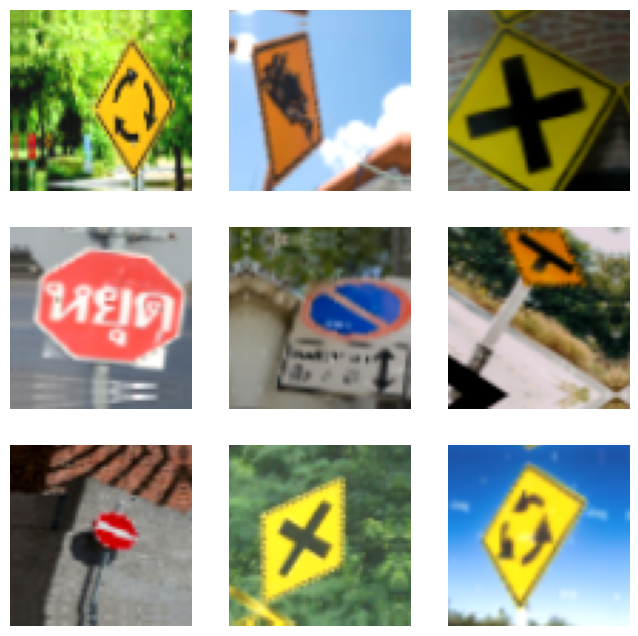

In [ ]:
# augmented images visualization
"""
visualize the augmented images to see the result
since the augmented images are not saved within the folder
we have to visualize it through pyplot to see the actual augmented images
"""

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(8,8))

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        img = tf.clip_by_value(images[i], 0, 255)
        plt.imshow(img.numpy().astype("uint8"))

        plt.axis("off")

    plt.show()

In [ ]:
# normalization
"""
since image pixel values are range from 0 to 255
the model performs better and train faster when the input
features are on a smaller scale

every pixel value in the images will be multiplied by 1/255
changes from the range 0 to 255, into 0 to 1
improving the training and testing (validation) process
"""

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
# optimization
"""
AUTONTUNE - allows TensorFlow to decide the optimal value
            at runtime based on system's capabilities, leading to
            better performance without manual tuning

cache - once the elements are loaded from disk, cache stores them in memory
        so the next time the dataset is iterated, these cache elements are reused,
        speeding up the training epochs

shuffle - shuffles the elements of the dataset. the 1000 is the buffer size.
          creates a buffer of 1000 elements and then randomly samples elements
          from this buffer, preventing the model from learning
          spurious correlations. (two variables that appear related but
          acutally has no connection)

prefetch - prepares the next batch in the background when the current batch is
           being trained, minimizing idle time
"""

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

In [ ]:
# CNN model
"""
Conv2D - learns features by sliding/convolving a small filter(kernel)
         over the input images

32 - number of filters(kernels) the layer will learn. each filter learns
     to detect a different feature (edges, textures, etc.)

(3,3) - the size of the convolutional pixel, 3x3 pixel window
        will slide over the image

activation='relu' - uses Rectified Linear Unit (ReLU) activation function.
                    Introduces non-linearity, allowing the network
                    to learn more complex patterns

input_shape = defines the expected shape of the input images (64, 64).
              3 indicates the number of color channels (RGB)
"""
model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(8, activation='softmax')  # 8 traffic sign classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# complie model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# implement early stopping
"""
early stop stops training before overfitting
"""

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# train model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30, # 30 epochs since low amount of dataset
    callbacks=[early_stop]
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 485ms/step - accuracy: 0.1215 - loss: 2.0995 - val_accuracy: 0.1233 - val_loss: 2.0942
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1651 - loss: 2.0496 - val_accuracy: 0.1781 - val_loss: 2.0169
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2172 - loss: 1.9400 - val_accuracy: 0.2055 - val_loss: 1.8442
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2800 - loss: 1.7158 - val_accuracy: 0.2603 - val_loss: 1.6539
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3577 - loss: 1.6240 - val_accuracy: 0.3151 - val_loss: 1.5067
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4906 - loss: 1.4009 - val_accuracy: 0.3151 - val_loss: 1.5961
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4202 - loss: 1.4379 - val_accuracy: 0.4247 - val_loss: 1.3592
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4669 - loss: 1.3192 - val_accuracy: 0.2877 - 

In [ ]:
# test accuracy
loss, accuracy = model.evaluate(validation_dataset)

print("Test accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5181 - loss: 1.1408
Test accuracy: 0.5205479264259338


In [ ]:
# y_pred, y_pred_classes
"""
y_pred - raw prediction probabilities from the trained model

y_pred_classes - the predicted class label for each image
"""

y_pred = model.predict(validation_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step


In [ ]:
# y_true
"""
y_true - the actual class labels for the images. used for
         evaluating the performance of the model
"""

y_true = []

for images, labels in validation_dataset:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

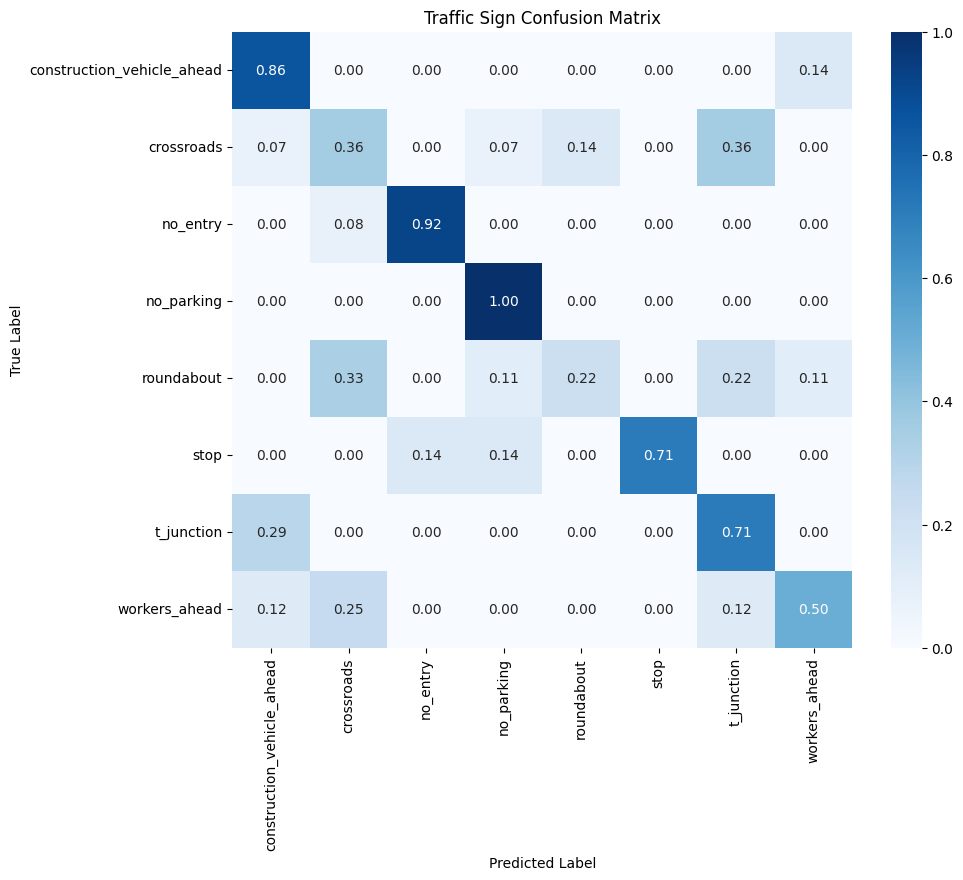

In [ ]:
# confusion matrix
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Traffic Sign Confusion Matrix")

plt.show()

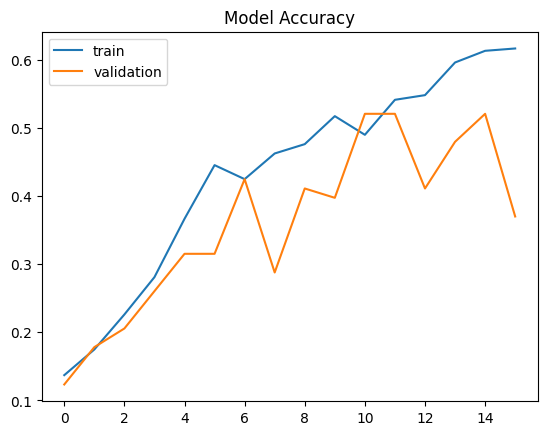

In [ ]:
# model accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','validation'])
plt.title("Model Accuracy")
plt.show()

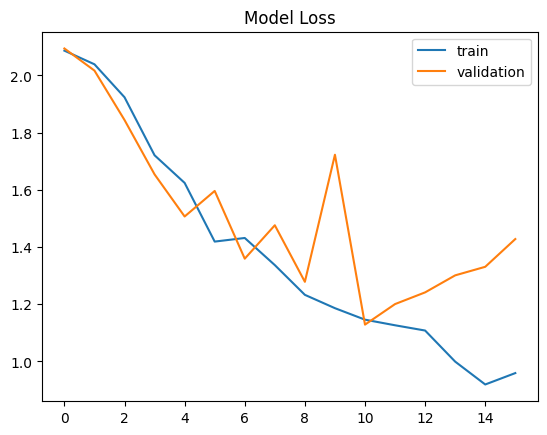

In [ ]:
# model loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.title("Model Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


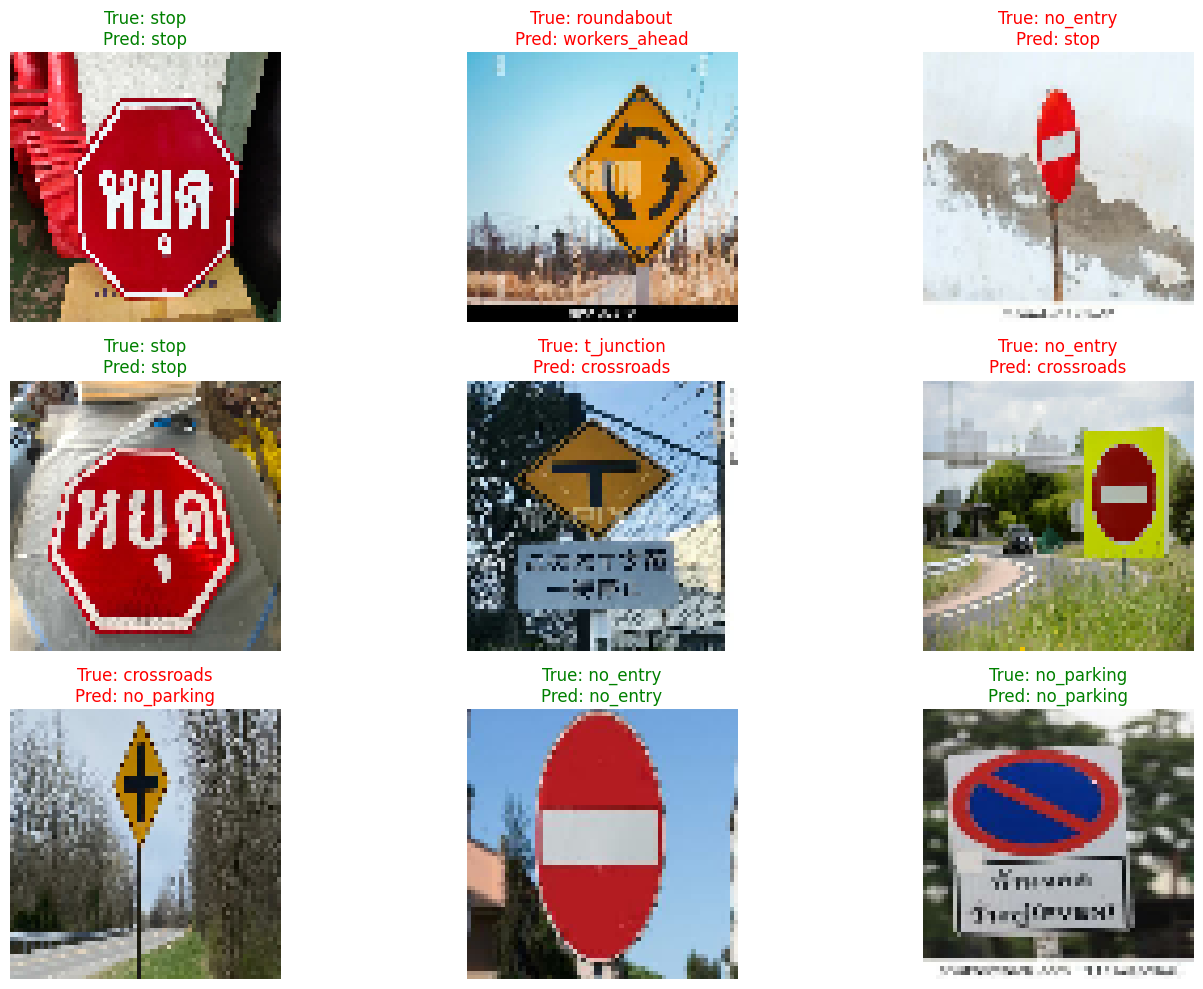

In [ ]:
# prediction samples
"""
get a batch of images and labels from the validation dataset and
make predictions on the selected batch

use value 0 to 1 since the data has already been normalized

if the predicted label and the true label matches, the text
will display as green, if not display red
"""

for images, labels in validation_dataset.take(1):

    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    plt.figure(figsize=(15, 10))

    for i in range(min(9, images.shape[0])):

        plt.subplot(3, 3, i + 1)
        img_display = tf.clip_by_value(images[i], 0.0, 1.0)
        plt.imshow(img_display.numpy())

        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[predicted_classes[i]]

        color = "green" if true_label == predicted_label else "red"
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# classification report
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

                            precision    recall  f1-score   support

construction_vehicle_ahead       0.80      0.57      0.67         7
                crossroads       0.50      0.50      0.50        14
                  no_entry       0.80      0.31      0.44        13
                no_parking       0.57      1.00      0.73         8
                roundabout       0.14      0.11      0.12         9
                      stop       0.46      0.86      0.60         7
                t_junction       0.50      0.14      0.22         7
             workers_ahead       0.54      0.88      0.67         8

                  accuracy                           0.52        73
                 macro avg       0.54      0.55      0.49        73
              weighted avg       0.55      0.52      0.49        73



In [ ]:
# save the model
"""
save the model and use it for the webcam
traffic sign detector in vscode
"""

model.save("traffic_sign_model.h5")